In [2]:
print("emo and sara")

emo and sara


In [3]:
import mne

edf_file = "Dataset/Signals/mesa-sleep-0002.edf"
raw = mne.io.read_raw_edf(edf_file, preload=False)

print("Channel names in EDF file:")
print(raw.ch_names)

Extracting EDF parameters from Dataset/Signals/mesa-sleep-0002.edf...
Setting channel info structure...
Creating raw.info structure...
Channel names in EDF file:
['EKG', 'EOG-L', 'EOG-R', 'EMG', 'EEG1', 'EEG2', 'EEG3', 'Pres', 'Flow', 'Snore', 'Thor', 'Abdo', 'Leg', 'Therm', 'Pos', 'EKG_Off', 'EOG-L_Off', 'EOG-R_Off', 'EMG_Off', 'EEG1_Off', 'EEG2_Off', 'EEG3_Off', 'Pleth', 'OxStatus', 'SpO2', 'HR', 'DHR']


Extracting EDF parameters from Dataset/Signals/mesa-sleep-0010.edf...
Setting channel info structure...
Creating raw.info structure...


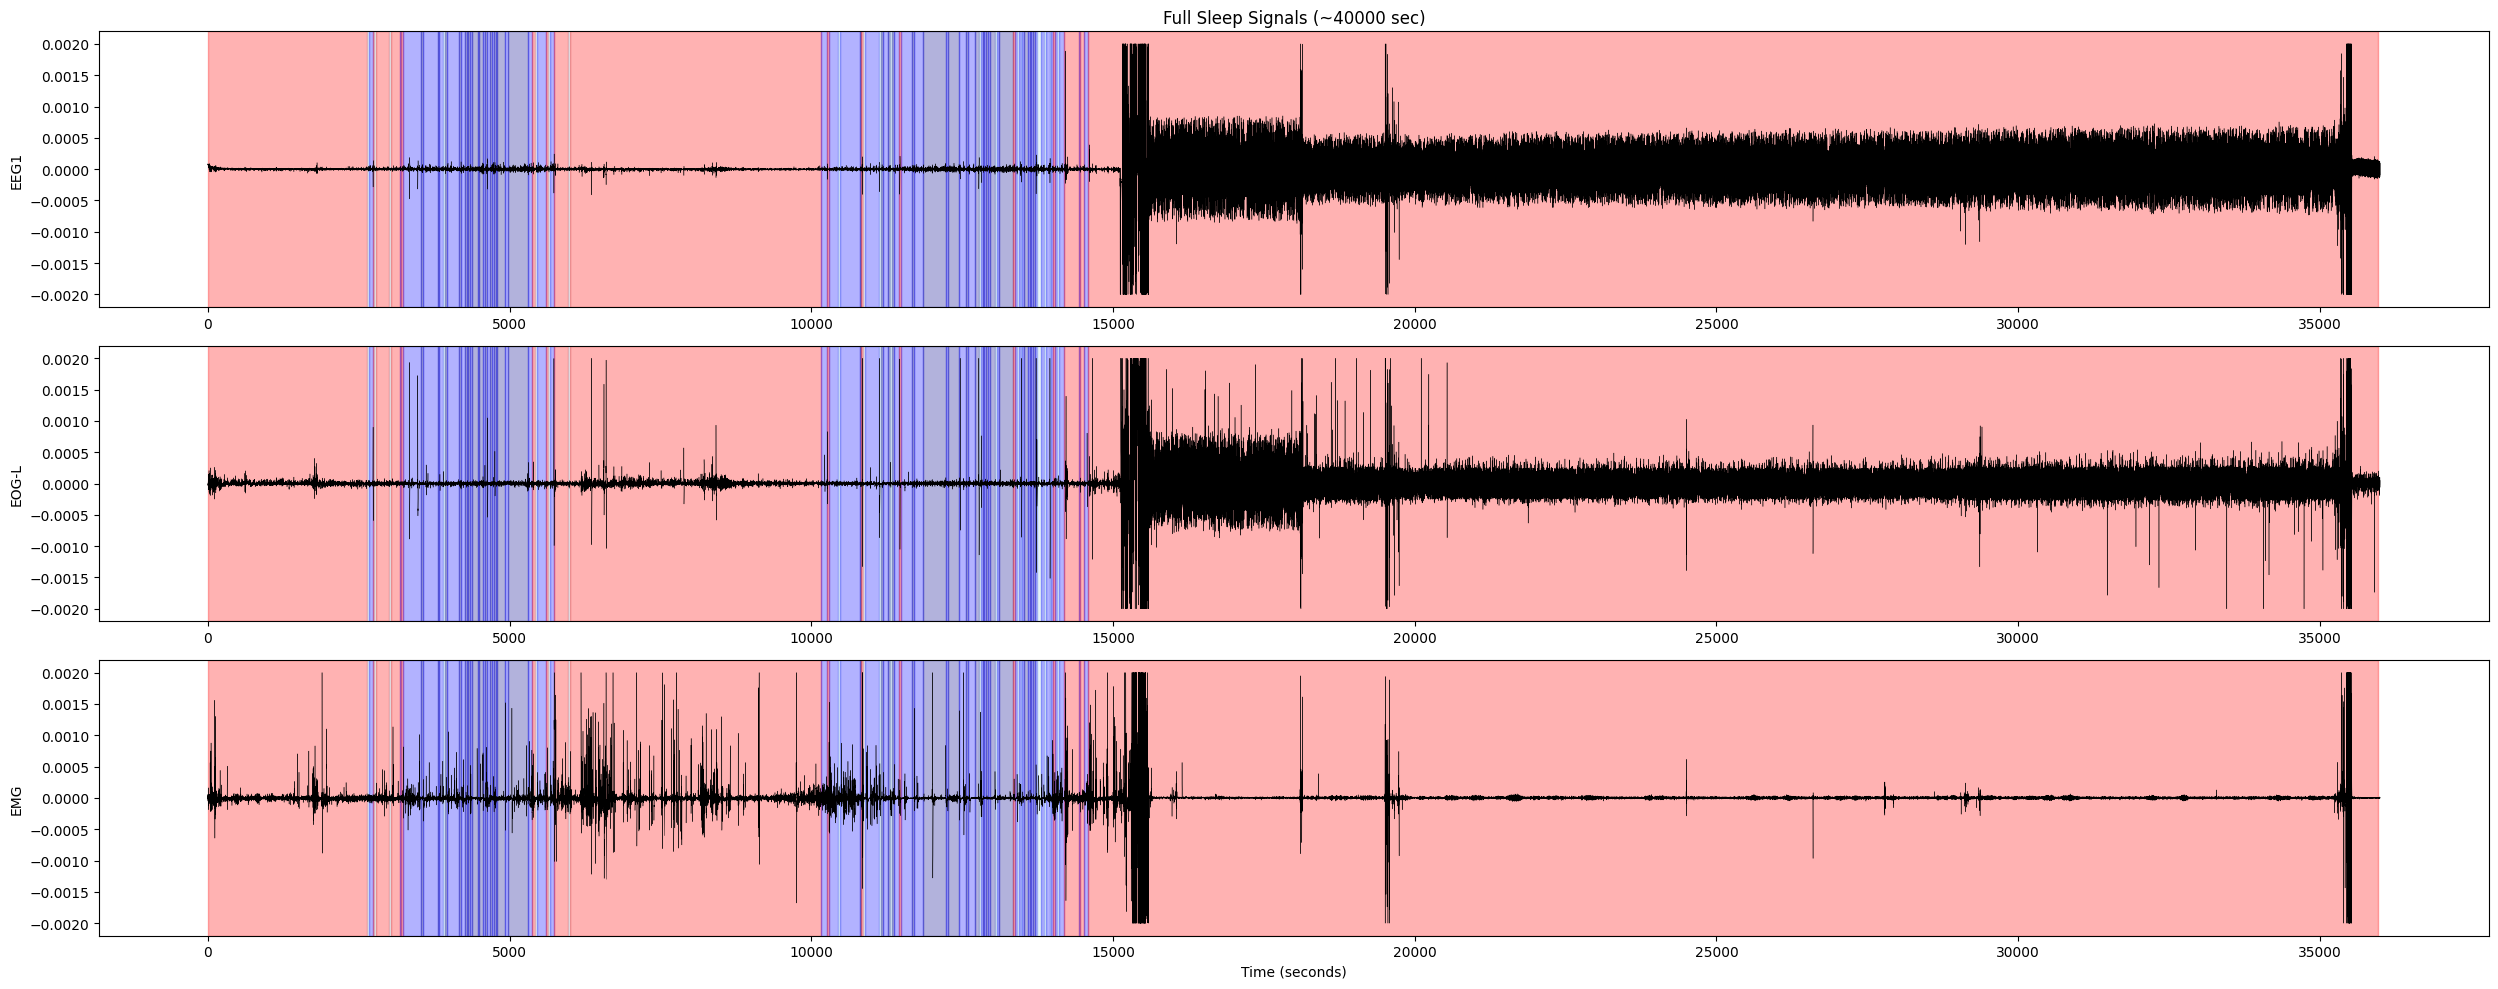

In [8]:
import mne
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import numpy as np

edf_file = "Dataset/Signals/mesa-sleep-0010.edf"
xml_file = "Dataset/Annotations/mesa-sleep-0010-nsrr.xml"

channels_to_plot = ['EEG1', 'EOG-L', 'EMG']

# قراءة XML
tree = ET.parse(xml_file)
root = tree.getroot()

events = [e for e in root.findall(".//ScoredEvent")
          if e.find("EventType").text == "Stages|Stages"]

colors = {
    "Wake|0": "red",
    "Stage 1 sleep|1": "lightblue",
    "Stage 2 sleep|2": "blue",
    "Stage 3 sleep|3": "darkblue",
    "REM sleep|5": "green"
}

raw = mne.io.read_raw_edf(edf_file, preload=False)
sfreq = raw.info['sfreq']

plt.figure(figsize=(25, 10))

for i, ch in enumerate(channels_to_plot):
    ax = plt.subplot(len(channels_to_plot), 1, i + 1)

    data = raw.get_data(picks=ch)[0]
    times = np.arange(len(data)) / sfreq


    step = 200
    data = data[::step]
    times = times[::step]

    # رسم الإشارة
    ax.plot(times, data, color='black', linewidth=0.3)

    # رسم الـ stages
    for e in events:
        start = float(e.find("Start").text)
        duration = float(e.find("Duration").text)
        stage = e.find("EventConcept").text
        color = colors.get(stage, "gray")

        ax.axvspan(start, start + duration, color=color, alpha=0.3)

    ax.set_ylabel(ch)

    if i == 0:
        ax.set_title("Full Sleep Signals (~40000 sec)")

    if i == len(channels_to_plot) - 1:
        ax.set_xlabel("Time (seconds)")

plt.tight_layout()
plt.show()

In [ ]:
data split

In [ ]:
import os
import shutil
import numpy as np

edf_dir = "Dataset/Signals"
xml_dir = "Dataset/Annotations"
files = [f.replace(".edf","") for f in os.listdir(edf_dir) if f.endswith(".edf")]
files.sort() 

In [ ]:
np.random.seed(42) 
np.random.shuffle(files)

n = len(files)
train_end = int(n*0.7)
val_end = int(n*0.85)

train_files = files[:train_end]
val_files = files[train_end:val_end]
test_files = files[val_end:]

In [ ]:
for split in ["train","val","test"]:
    os.makedirs(f"Dataset/{split}/Signals", exist_ok=True)
    os.makedirs(f"Dataset/{split}/Annotations", exist_ok=True)


for f in train_files:
    shutil.copy(os.path.join(edf_dir,f+".edf"), f"Dataset/train/Signals/")
    shutil.copy(os.path.join(xml_dir,f+"-nsrr.xml"), f"Dataset/train/Annotations/")

for f in val_files:
    shutil.copy(os.path.join(edf_dir,f+".edf"), f"Dataset/val/Signals/")
    shutil.copy(os.path.join(xml_dir,f+"-nsrr.xml"), f"Dataset/val/Annotations/")

for f in test_files:
    shutil.copy(os.path.join(edf_dir,f+".edf"), f"Dataset/test/Signals/")
    shutil.copy(os.path.join(xml_dir,f+"-nsrr.xml"), f"Dataset/test/Annotations/")

In [ ]:
import os
import mne
import numpy as np
import xml.etree.ElementTree as ET

# Processing Configuration & Scientific Rationale
# Selecting EEG (Brain), EOG (Eyes), and EMG (Muscles) provides the 'Gold Standard' 
# for sleep staging according to AASM (American Academy of Sleep Medicine) guidelines.
CHANNELS = ['EEG1', 'EOG-L', 'EMG']
# Downsampling to 100Hz reduces computational complexity while keeping the Nyquist frequency (50Hz)
# well above the important brain wave frequencies like Delta (0.5-4Hz) and Alpha (8-13Hz).
TARGET_SFREQ = 100  
EPOCH_SEC = 30   # Standard clinical window duration for sleep stage scoring. 
EPOCH_LENGTH = TARGET_SFREQ * EPOCH_SEC  

STAGE_MAPPING = {
    "Wake|0": 0,
    "Stage 1 sleep|1": 1,
    "Stage 2 sleep|2": 2,
    "Stage 3 sleep|3": 3,
    "REM sleep|5": 4
}

def process_single_record(edf_path, xml_path):
 
    raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
    raw.pick_channels(CHANNELS)
    raw.resample(TARGET_SFREQ, npad="auto", verbose=False)
    data = raw.get_data().T 
    tree = ET.parse(xml_path)
    root = tree.getroot()
    events = [e for e in root.findall(".//ScoredEvent") if e.find("EventType").text == "Stages|Stages"]
    num_epochs = int(data.shape[0] / EPOCH_LENGTH)
    labels = np.full(num_epochs, -1)
    
    for e in events:
        start_time = float(e.find("Start").text)
        duration = float(e.find("Duration").text)
        stage_str = e.find("EventConcept").text
        
        if stage_str in STAGE_MAPPING:
            start_epoch = int(start_time / EPOCH_SEC)
            num_stage_epochs = int(duration / EPOCH_SEC)
            for i in range(start_epoch, min(start_epoch + num_stage_epochs, num_epochs)):
                labels[i] = STAGE_MAPPING[stage_str]
    data = data[:num_epochs * EPOCH_LENGTH]
    
    X = data.reshape(num_epochs, EPOCH_LENGTH, len(CHANNELS))
    y = labels

    valid_indices = (y != -1)
    
    return X[valid_indices], y[valid_indices]
splits = ["train", "val", "test"]

for split in splits:
    print(f"\n Processing {split.upper()} data...")
    
    signals_dir = f"Dataset/{split}/Signals"
    annotations_dir = f"Dataset/{split}/Annotations"
    save_dir = f"Dataset/Processed/{split}"
    
    os.makedirs(save_dir, exist_ok=True)
    
    files = [f.replace(".edf", "") for f in os.listdir(signals_dir) if f.endswith(".edf")]

    X_all = []
    y_all = []
    
    for f in files:
        edf_path = os.path.join(signals_dir, f + ".edf")
        xml_path = os.path.join(annotations_dir, f + "-nsrr.xml")
        
        try:
            X_subj, y_subj = process_single_record(edf_path, xml_path)
            X_all.append(X_subj)
            y_all.append(y_subj)
            print(f" Processed: {f} | Shape: X={X_subj.shape}, y={y_subj.shape}")
        except Exception as e:
            print(f" Error processing {f}: {e}")
            
    if X_all:
        X_split = np.vstack(X_all)
        y_split = np.concatenate(y_all)
        save_path = os.path.join(save_dir, f"{split}_data.npz")
        np.savez_compressed(save_path, X=X_split, y=y_split)
        print(f" Saved {split} data to {save_path} | Final Shape: X={X_split.shape}, y={y_split.shape}")


🚀 Processing TRAIN data...
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
✅ Processed: mesa-sleep-0002 | Shape: X=(1319, 3000, 3), y=(1319,)
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
✅ Processed: mesa-sleep-0006 | Shape: X=(1079, 3000, 3), y=(1079,)
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
✅ Processed: mesa-sleep-0012 | Shape: X=(1427, 3000, 3), y=(1427,)
🎉 Saved train data to Dataset/Processed/train\train_data.npz | Final Shape: X=(3825, 3000, 3), y=(3825,)

🚀 Processing VAL data...
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
✅ Processed: mesa-sleep-0001 | Shape: X=(1439, 3000, 3), y=(1439,)
🎉 Saved val data to Dataset/Processed/val\val_data.npz | Final Shape: X=(1439, 3000, 3), y=(1439,)

🚀 Processing TEST data...
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
✅ Processed: mesa-sleep-0010 | Shape: X=(1199, 

In [ ]:
import numpy as np


class_names = ['Wake', 'N1', 'N2', 'N3', 'REM']

def analyze_distribution(y, set_name="Training"):

    unique, counts = np.unique(y, return_counts=True)
    counts_dict = dict(zip(unique, counts))
    
    print(f"\n--- {set_name} Set Distribution ---")
    total = len(y)
    for i, name in enumerate(class_names):
        count = counts_dict.get(i, 0)
        percentage = (count / total) * 100
        print(f"{name} (Class {i}): {count} samples ({percentage:.2f}%)")

analyze_distribution(y_train, "Training")
analyze_distribution(y_test, "Testing")


--- Training Set Distribution ---
Wake (Class 0): 1817 samples (47.50%)
N1 (Class 1): 275 samples (7.19%)
N2 (Class 2): 1118 samples (29.23%)
N3 (Class 3): 247 samples (6.46%)
REM (Class 4): 368 samples (9.62%)

--- Testing Set Distribution ---
Wake (Class 0): 980 samples (81.73%)
N1 (Class 1): 20 samples (1.67%)
N2 (Class 2): 126 samples (10.51%)
N3 (Class 3): 73 samples (6.09%)
REM (Class 4): 0 samples (0.00%)


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import class_weight


print("Loading processed data...")
train_data = np.load("Dataset/Processed/train/train_data.npz")
val_data = np.load("Dataset/Processed/val/val_data.npz")
test_data = np.load("Dataset/Processed/test/test_data.npz")

X_train, y_train = train_data['X'], train_data['y']
X_val, y_val = val_data['X'], val_data['y']
X_test, y_test = test_data['X'], test_data['y']

print(f"Data Loaded! Train shape: {X_train.shape}")

Loading processed data...
Data Loaded! Train shape: (3825, 3000, 3)


In [19]:
unique_classes = np.unique(y_train)
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=unique_classes,
    y=y_train
)
class_weights_dict = dict(enumerate(weights))

print("\n--- Calculated Class Weights ---")
class_names = ['Wake', 'N1', 'N2', 'N3', 'REM']
for i, name in enumerate(class_names):
    print(f"{name}: {class_weights_dict[i]:.2f}")


--- Calculated Class Weights ---
Wake: 0.42
N1: 2.78
N2: 0.68
N3: 3.10
REM: 2.08


In [ ]:

from tensorflow.keras import optimizers

def build_model(input_shape):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        
      
        layers.Conv1D(128, kernel_size=50, strides=6, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=8, strides=8),
        
        layers.Conv1D(256, kernel_size=8, strides=1, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv1D(256, kernel_size=8, strides=1, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=4, strides=4),
        
      
        layers.Dropout(0.4),
        
      
        layers.Bidirectional(layers.LSTM(128, return_sequences=True)),
        layers.Bidirectional(layers.LSTM(128)),
        layers.Dropout(0.5),
        
        
        layers.Dense(128, activation='relu'),
        layers.Dense(5, activation='softmax')
    ])
    

    opt = optimizers.RMSprop(learning_rate=0.00005) 
    model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


input_shape = (X_train.shape[1], X_train.shape[2])
model = build_model(input_shape)
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_12 (Conv1D)              │ (None, 500, 128)       │        19,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 500, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_8 (MaxPooling1D)  │ (None, 62, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_13 (Conv1D)              │ (None, 62, 256)        │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 62, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_14 (Conv1D)              │ (None, 62, 256)        │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 62, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_9 (MaxPooling1D)  │ (None, 15, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 15, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_8 (Bidirectional) │ (None, 15, 256)        │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_9 (Bidirectional) │ (None, 256)            │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,630,853 (6.22 MB)

 Trainable params: 1,629,573 (6.22 MB)

 Non-trainable params: 1,280 (5.00 KB)

In [34]:
refined_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1)
]

In [35]:
print("\nStarting Power Training with Balanced Weights...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    shuffle=True,
    class_weight=class_weights_dict, 
    callbacks=refined_callbacks
)


Starting Power Training with Balanced Weights...
Epoch 1/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 23s 155ms/step - accuracy: 0.4227 - loss: 1.4543 - val_accuracy: 0.5226 - val_loss: 1.5822 - learning_rate: 5.0000e-05
Epoch 2/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 17s 142ms/step - accuracy: 0.5153 - loss: 1.2192 - val_accuracy: 0.5226 - val_loss: 1.5623 - learning_rate: 5.0000e-05
Epoch 3/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 18s 146ms/step - accuracy: 0.5610 - loss: 1.0732 - val_accuracy: 0.5226 - val_loss: 1.5598 - learning_rate: 5.0000e-05
Epoch 4/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 16s 132ms/step - accuracy: 0.5992 - loss: 0.9880 - val_accuracy: 0.0229 - val_loss: 1.6961 - learning_rate: 5.0000e-05
Epoch 5/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 16s 133ms/step - accuracy: 0.6243 - loss: 0.9277 - val_accuracy: 0.0236 - val_loss: 1.9242 - learning_rate: 5.0000e-05
Epoch 6/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.6558 - loss: 0.8709
Epoch 6: ReduceLROnPlateau reducing learning rate to 2.499999

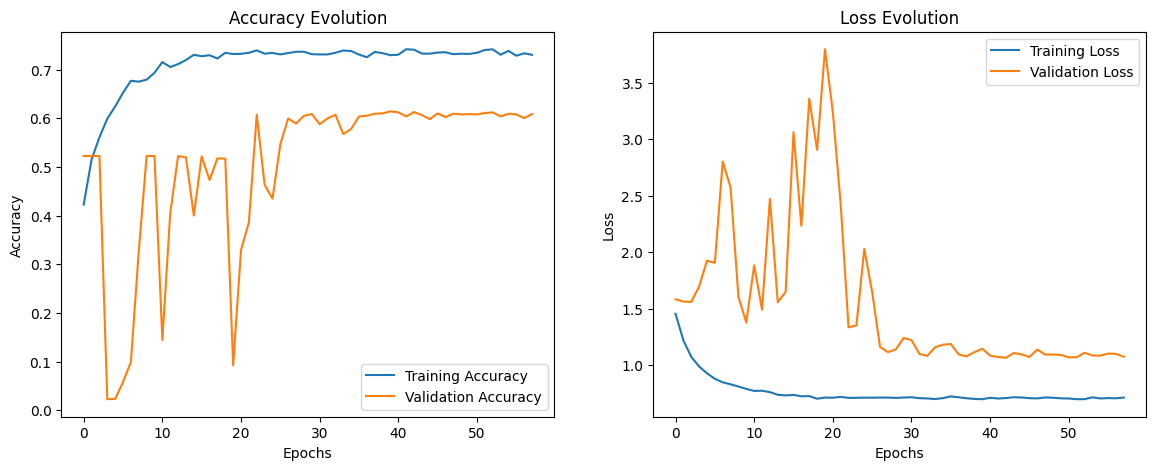

In [ ]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Evolution')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Evolution')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
print("\nEvaluating on Test Data...")
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
class_names = ['Wake', 'N1', 'N2', 'N3', 'REM']

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))


Evaluating on Test Data...
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step

Classification Report:
              precision    recall  f1-score   support

        Wake       0.95      0.96      0.95       980
          N1       1.00      0.05      0.10        20
          N2       0.53      0.29      0.38       126
          N3       0.49      0.79      0.60        73
         REM       0.00      0.00      0.00         0

    accuracy                           0.86      1199
   macro avg       0.59      0.42      0.41      1199
weighted avg       0.88      0.86      0.86      1199



c:\Users\eman sabry\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\eman sabry\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\eman sabry\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

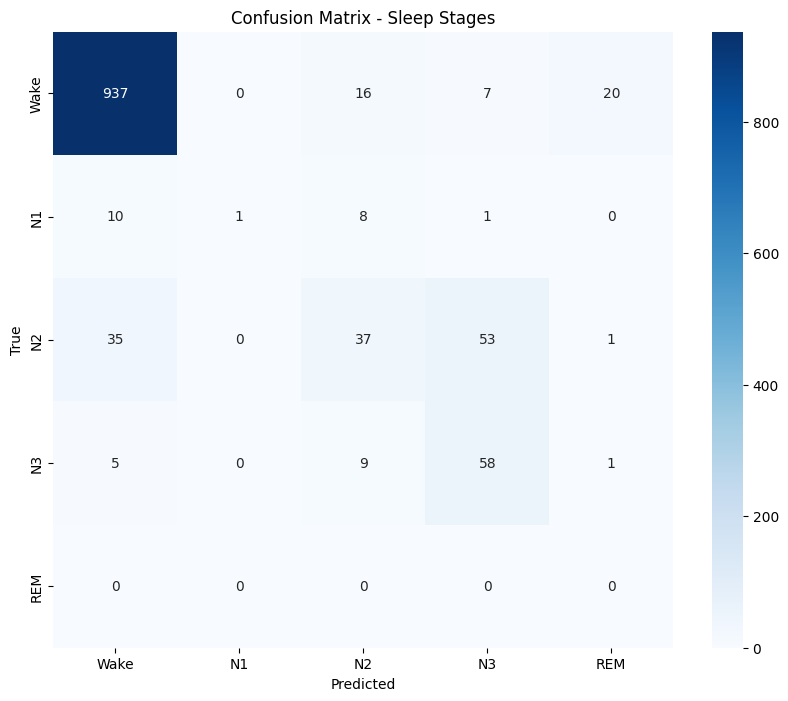

In [38]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Sleep Stages')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [39]:
y_pred_val = np.argmax(model.predict(X_val), axis=1)
print(classification_report(y_val, y_pred_val, target_names=['Wake', 'N1', 'N2', 'N3', 'REM'], zero_division=0))

45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step
              precision    recall  f1-score   support

        Wake       0.95      0.61      0.74       752
          N1       0.44      0.13      0.20       135
          N2       0.71      0.72      0.72       455
          N3       0.12      0.79      0.21        19
         REM       0.20      0.85      0.32        78

    accuracy                           0.61      1439
   macro avg       0.48      0.62      0.44      1439
weighted avg       0.78      0.61      0.65      1439

